Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cleaned Dataset Shape: (48536, 14)
Total Missing After Cleaning: 0

Logistic Regression (ALL FEATURES) | Target = Category
Features = ALL (after cleaning)
Accuracy: 0.3105686032138443
                       precision    recall  f1-score   support

  Cis-acting Modifier       0.24      0.38      0.30      2406
        Primary Cause       0.25      0.34      0.29      2446
Trans-acting Modifier       0.49      0.26      0.34      4856

             accuracy                           0.31      9708
            macro avg       0.33      0.33      0.31      9708
         weighted avg       0.37      0.31      0.32      9708



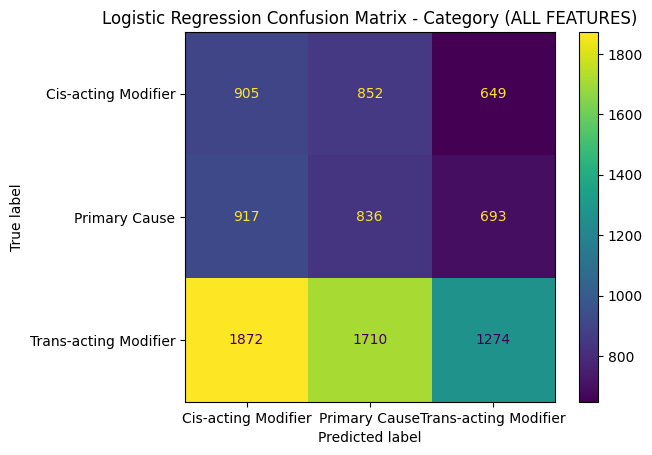


Logistic Regression (ALL FEATURES) | Target = Motor_Symptoms
Features = ALL (after cleaning)
Accuracy: 0.3354964977338278
              precision    recall  f1-score   support

        Mild       0.32      0.28      0.30      3224
    Moderate       0.35      0.31      0.32      3252
      Severe       0.34      0.42      0.37      3232

    accuracy                           0.34      9708
   macro avg       0.34      0.34      0.33      9708
weighted avg       0.34      0.34      0.33      9708



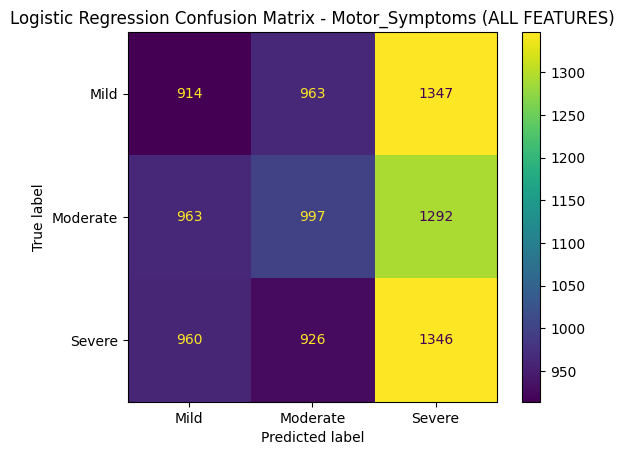


Logistic Regression (ALL FEATURES) | Target = Disease_Stage
Features = ALL (after cleaning)
Accuracy: 0.2535022661722291
                 precision    recall  f1-score   support

          Early       0.25      0.29      0.27      2407
           Late       0.26      0.19      0.22      2405
         Middle       0.26      0.22      0.24      2458
Pre-Symptomatic       0.25      0.32      0.28      2438

       accuracy                           0.25      9708
      macro avg       0.25      0.25      0.25      9708
   weighted avg       0.25      0.25      0.25      9708



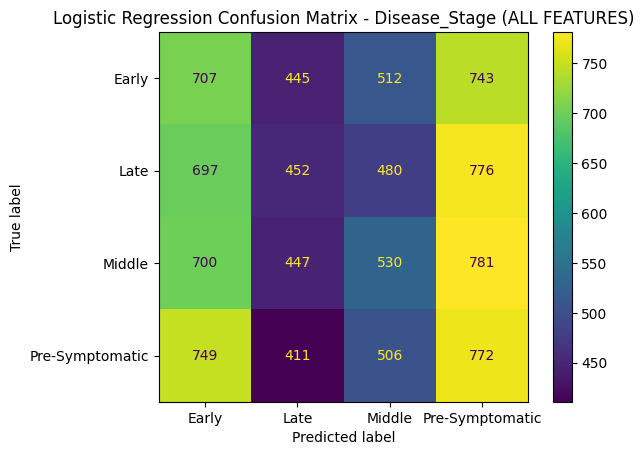


Logistic Regression (NECESSARY FEATURES) | Target = Category
Features = Necessary (13)
Accuracy: 0.3105686032138443
                       precision    recall  f1-score   support

  Cis-acting Modifier       0.24      0.38      0.30      2406
        Primary Cause       0.25      0.34      0.29      2446
Trans-acting Modifier       0.49      0.26      0.34      4856

             accuracy                           0.31      9708
            macro avg       0.33      0.33      0.31      9708
         weighted avg       0.37      0.31      0.32      9708



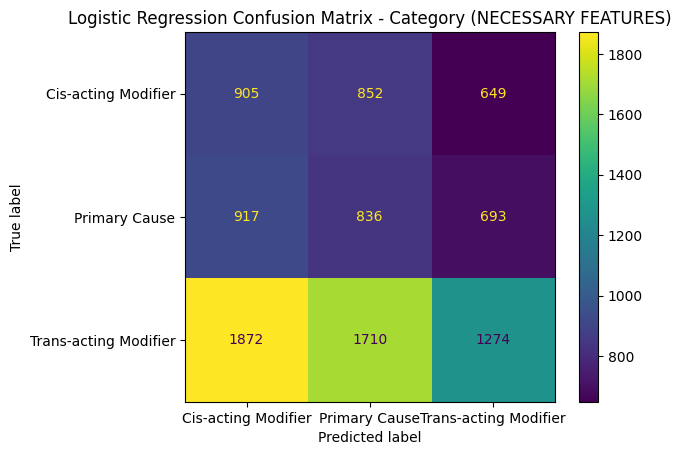

(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 LabelEncoder())

In [8]:
# ============================================================
# INSTALL (Colab/Jupyter only)
# ============================================================
!pip -q install -U scikit-learn

import warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

# ============================================================
# CONFIG
# ============================================================
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset_Raw.csv"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# 0) LOAD + PREPROCESS
# ============================================================

df = pd.read_csv(DATA_PATH)

# Remove noisy / unnecessary columns
noise_cols = [
    "Patient_ID",
    "Random_Protein_Sequence",
    "Random_Gene_Sequence",
    "Gene/Factor",
    "Function",
    "Effect",
    "Chromosome_Location"
]

df = df.drop(columns=[c for c in noise_cols if c in df.columns], errors="ignore")

# Handle Missing Values
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].fillna(df[c].mode()[0])

for c in df.select_dtypes(include=np.number).columns:
    df[c] = df[c].fillna(df[c].median())

# Convert object to string
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].astype(str)

print("Cleaned Dataset Shape:", df.shape)
print("Total Missing After Cleaning:", df.isnull().sum().sum())

# ============================================================
# 1) LOGISTIC REGRESSION FUNCTION
# ============================================================

def run_logistic_regression(df_in, target, feature_cols=None, title=""):

    data = df_in.copy()

    # Select features
    if feature_cols is None:
        X = data.drop(columns=[target])
    else:
        X = data[feature_cols].copy()

    y = data[target].copy()

    # One-hot encode features
    X = pd.get_dummies(X, drop_first=False)

    # Encode target labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded,
        test_size=0.2,
        random_state=SEED,
        stratify=y_encoded
    )

    # Scale features (IMPORTANT for Logistic Regression)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Logistic Regression Model
    model = LogisticRegression(
        max_iter=1000,
     class_weight="balanced",
        solver="lbfgs",
        random_state=SEED
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print("\n" + "="*70)
    print(f"Logistic Regression {title} | Target = {target}")

    if feature_cols is None:
        print("Features = ALL (after cleaning)")
    else:
        print(f"Features = Necessary ({len(feature_cols)})")

    print("Accuracy:", acc)
    print(classification_report(y_test, preds, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(values_format="d")
    plt.title(f"Logistic Regression Confusion Matrix - {target} {title}")
    plt.show()

    return model, le


# ============================================================
# A) LOGISTIC REGRESSION ON ALL FEATURES (3 TARGETS)
# ============================================================

targets_all = ["Category", "Motor_Symptoms", "Disease_Stage"]

for t in targets_all:
    if t in df.columns:
        run_logistic_regression(
            df,
            target=t,
            feature_cols=None,
            title="(ALL FEATURES)"
        )

# ============================================================
# B) LOGISTIC REGRESSION FOR CATEGORY USING NECESSARY FEATURES
# ============================================================

necessary_features = [
    "Age",
    "Sex",
    "Family_History",
    "HTT_CAG_Repeat_Length",
    "Gene_Mutation_Type",
    "HTT_Gene_Expression_Level",
    "Protein_Aggregation_Level",
    "Brain_Volume_Loss",
    "Functional_Capacity",
    "Cognitive_Decline",
    "Chorea_Score",
    "Motor_Symptoms",
    "Disease_Stage"
]

# Keep only existing columns
necessary_features = [c for c in necessary_features if c in df.columns]

run_logistic_regression(
    df,
    target="Category",
    feature_cols=necessary_features,
    title="(NECESSARY FEATURES)"
)